In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import logging
logging.basicConfig(level=logging.INFO)

## Deriving selection functions for the $x_1$ and $c$ parameters, and offset for absolute mag
This notebook simulate Nx times the number of SN Ia expected from ZTF using flat x_1/c distributions to derive selection functions. It also calculate the offset to be applied to the luminosity function to account for selection effect.

In [3]:
quick_test=False
N=3
NSIM = 10000
RANDSEED = 1101

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
import cloudpickle as pickle
from regions import RectangleSkyRegion
from astropy.coordinates import SkyCoord
import astropy.units as u
from scipy.optimize import curve_fit
import inspect
from IPython.display import display, Markdown

from lightcurvelynx.obstable.ztf_obstable import ZTFObsTable
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.astro_utils.pzflow_node import PZFlowNode
from lightcurvelynx.astro_utils.snia_utils import (
    DistModFromRedshift,
    HostmassX1Func,
    X0FromDistMod,
    num_snia_per_redshift_bin,
    SNCoordGivenPhysicalSep,
    snia_volumetric_rates,
)
from lightcurvelynx.math_nodes.scipy_random import SamplePDF
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.simulate import simulate_lightcurves
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.models.snia_host import SNIaHost
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.math_nodes.ra_dec_sampler import ObsTableUniformRADECSampler
from lightcurvelynx.astro_utils.dustmap import DustmapWrapper,SFDMap
from lightcurvelynx.effects.extinction import ExtinctionEffect
from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.astro_utils.detector_footprint import DetectorFootprint
from lightcurvelynx.utils.extrapolate import LinearDecayOnMag,ZeroPadding

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from utils.analysis_utils import lc_quality_cuts, spec_selection_func

from ztf_snia_sim_params import SIM_PARAMS

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [5]:
RNG = np.random.default_rng(RANDSEED)

In [6]:
# load and define constants that are used throughout the simulations
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
ZMIN, ZMAX = SIM_PARAMS["zmin"], SIM_PARAMS["zmax"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

ZP_ERR_MAG = SIM_PARAMS["zp_mag_err"]

X1_MIN, X1_MAX = SIM_PARAMS["x1min"], SIM_PARAMS["x1max"]
C_MIN, C_MAX = SIM_PARAMS["cmin"], SIM_PARAMS["cmax"]
NBINS_X1C_PDF = 30

X1_BINS = np.linspace(X1_MIN,X1_MAX,NBINS_X1C_PDF)
C_BINS = np.linspace(C_MIN,C_MAX,NBINS_X1C_PDF)

In [7]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [8]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [9]:
%%time

obs_log = pd.read_parquet('data/ztf_observing_log_combined_w_metadata.parquet')
colmap = {"ra":"ra",
          "dec":"dec",
          "time":"mjd",
          "zp":"zp_nJy",
          "filter":"filter",
          "sky":"sky_adu_ztfsn",
         }

#ztf ccd size 6144 × 6160 pixel * 16
pixel_scale = 1.01 #arcsec/pixel
center = SkyCoord(ra=0.0, dec=0.0, unit="deg", frame="icrs")
rect_region = RectangleSkyRegion(center=center, width=4*6144.* pixel_scale * u.arcsec, 
                                 height=4*6160.* pixel_scale * u.arcsec, angle=0.0 * u.deg)
ztf_fp = DetectorFootprint(rect_region, pixel_scale=pixel_scale)

ztf_obstable = ZTFObsTable(obs_log,colmap=colmap,detector_footprint=ztf_fp)
ztf_obstable.survey_values["zp_err_mag"] = ZP_ERR_MAG

t_min, t_max = ztf_obstable.time_bounds()
print(f"Loaded OpSim with {len(ztf_obstable)} rows and times [{t_min}, {t_max}]")

passband_group = PassbandGroup.from_preset(preset="ZTF", filters=["g", "r", "i"])
print(f"Loaded Passbands: {passband_group}")

INFO:lightcurvelynx.obstable.obs_table:Provided radius 3.868 is smaller than footprint radius 4.871029037867509. Using the footprint radius instead.
INFO:lightcurvelynx.astro_utils.passbands:Loading passbands from preset ZTF


Loaded OpSim with 522192 rows and times [58288.171875, 59273.55859375]
Loaded Passbands: PassbandGroup containing 3 passbands: ZTF_g, ZTF_r, ZTF_i
CPU times: user 511 ms, sys: 95.7 ms, total: 607 ms
Wall time: 535 ms


In [10]:
radec_node = ObsTableUniformRADECSampler(ztf_obstable, node_label="radec")

rate = lambda z: 2.35e-5 #(2.35 ± 0.24) × 10^4 Gpc^−3 yr^−1 = (2.35 ± 0.24) × 10^4 * 10^-9 Mpc^−3 yr^−1, from ZTF BTS paper Perley et al. 2020

nsn, z = num_snia_per_redshift_bin(ZMIN, ZMAX, 100, H0=H0, Omega_m=OMEGA_M, vol_rate_function=rate)
zpdf = interp1d(z, nsn, bounds_error=False, fill_value=0)

host = SNIaHost(
    ra = radec_node.ra,
    dec = radec_node.dec,
    hostmass=10.,
    redshift=SamplePDF(zpdf),
    node_label="host",
)

In [11]:
distmod_func = DistModFromRedshift(host.redshift, H0=H0, Omega_m=OMEGA_M)
x1_func = NumpyRandomFunc("uniform",low=X1_MIN,high=X1_MAX)
c_func = NumpyRandomFunc("uniform",low=C_MIN,high=C_MAX)
m_abs_func = NumpyRandomFunc("normal", loc=MAGABS, scale=SIGMA_MAGABS)

# we model host-sn separation as an exponential distribution based on Fig 3 of Gupta et al 2016, mean separation = 5kpc
physical_host_sn_sep = NumpyRandomFunc("exponential", scale = 5.)
sncoor_node = SNCoordGivenPhysicalSep(host.ra, host.dec, physical_host_sn_sep, host.redshift, H0=H0, Omega_m=OMEGA_M,node_label='sncoor_node')

x0_func = X0FromDistMod(
    distmod=distmod_func,
    x1=x1_func,
    c=c_func,
    alpha=ALPHA,
    beta=BETA,
    m_abs=m_abs_func,
    node_label="x0_func",
)

sncosmo_modelname = "salt3"
time_extrap_before = ZeroPadding()
time_extrap_after = LinearDecayOnMag(decay_rate=0.02, mag_thres=30.)
wave_extrap_before = ZeroPadding()
wave_extrap_after = ZeroPadding()
source = SncosmoWrapperModel(
    sncosmo_modelname,
    t0=NumpyRandomFunc("uniform", low=t_min, high=t_max),
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=sncoor_node.ra,
    dec=sncoor_node.dec,
    redshift=host.redshift,
    node_label="source",
    time_extrapolation=(time_extrap_before,time_extrap_after),
    wave_extrapolation=(wave_extrap_before,wave_extrap_after),    
)
    
mwextinction = SFDMap(
    ra=source.ra,
    dec=source.dec,
    node_label="mwext",
)

# Create an extinction effect using the EBVs from that dust map.
ext_effect = ExtinctionEffect(extinction_model="F99", ebv=mwextinction, 
                              r_v=3.1,frame='observer',backend="dust_extinction")
source.add_effect(ext_effect)


INFO:lightcurvelynx.astro_utils.dustmap:SFD dust map data files not found.
Attempting to download from: ('https://github.com/kbarbary/sfddata/archive/master.tar.gz',)
to the directory /Users/mi/Work/lightcurvelynx/lightcurvelynx/data/dustmaps/sfdmap2


In [12]:
%%time
if quick_test:
    nsntotal = NSIM
else:
    survey_length = (t_max - t_min)/365.
    nsntotal, _ = num_snia_per_redshift_bin(ZMIN,ZMAX,1,solid_angle=9.136*survey_length*N,vol_rate_function=rate) 
    print(f"Survey length = {survey_length} years")
print(f"Simulating {int(nsntotal)} SN ...")

# lightcurves = simulate_lightcurves(source, int(nsntotal), ztf_obstable, passband_group,
#                                    param_cols = ['source.x0','source.x1','source.c','host.hostmass'])

lightcurves = simulate_lightcurves(
    model=source,
    num_samples=int(nsntotal),
    obstable=ztf_obstable,
    passbands=passband_group,
    param_cols = ['source.x0','source.x1','source.c','host.hostmass','x0_func.m_abs'],
    num_jobs=8,
    batch_size=5000,
    rng=RNG,
)

lightcurves

<timed exec>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
<timed exec>:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
INFO:lightcurvelynx.simulate:Using num_jobs=8 and batch_size=5000 for parallel processing.


Survey length = 2.6996896404109587 years
Simulating 315817 SN ...


Simulating:  23%|██▎       | 1167/5000 [00:09<00:30, 125.37obj/s]/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
Simulating:  10%|▉         | 478/5000 [00:04<00:49, 91.85obj/s]/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
Simulating:  65%|██████▍   | 3242/5000 [00:30<00:16, 109.24obj/s]/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
Simulating:  89%|████████▉ | 4462/5000 [00:39<00:04, 112.93obj/s]/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encount

CPU times: user 16.4 s, sys: 44.4 s, total: 1min
Wall time: 12min 44s


id          ra        dec  nobs            t0         z  \
0            0  334.567444 -15.384713   269  59078.517716  0.151850   
1            1    3.990179  21.184887   829  58606.777064  0.158896   
...        ...         ...        ...   ...           ...       ...   
315815  315815  298.382532  31.676665  1384  58402.806965  0.198229   
315816  315816  101.247896  -4.888235   682  58618.712388  0.153049   

                                                   params  source_x0  \
0       {'radec.ra': 334.56793703583287, 'radec.dec': ...   0.000581   
1       {'radec.ra': 3.990310193055122, 'radec.dec': 2...   0.000020   
...                                                   ...        ...   
315815  {'radec.ra': 298.3825904778141, 'radec.dec': 3...   0.000026   
315816  {'radec.ra': 101.24763444481651, 'radec.dec': ...   0.000009   

        source_x1  source_c  host_hostmass  x0_func_m_abs  \
0        2.073988 -0.282261           10.0     -19.374323   
1       -4.247150  0.478697           10.0     -19.148117   
...           ...       ...            ...            ...   
315815  -0.413183  0.391392           10.0     -19.109587   
315816  -2.933310  0.823541           10.0     -19.075079   

                                               lightcurve  
0       [{mjd: 58288.417969, filter: 'g', flux: 4990.3...  
1       [{mjd: 58289.433594, filter: 'g', flux: 426.24...  
...                                                   ...  
315815  [{mjd: 58288.445312, filter: 'r', flux: -1086....  
315816  [{mjd: 58365.515625, filter: 'r', flux: -7649....  

[315817 rows x 13 columns]

In [13]:
lightcurves['params'][0].keys()

dict_keys(['radec.ra', 'radec.dec', 'host.ra', 'host.dec', 'host.redshift', 'host.t0', 'host.distance', 'host.hostmass', 'SamplePDF:_rvs_4.function_node_result', 'sncoor_node.host_ra', 'sncoor_node.host_dec', 'sncoor_node.physical_sep_kpc', 'sncoor_node.redshift', 'sncoor_node.ra', 'sncoor_node.dec', 'NumpyRandomFunc:exponential_5.scale', 'NumpyRandomFunc:exponential_5.function_node_result', 'source.ra', 'source.dec', 'source.redshift', 'source.t0', 'source.distance', 'source.x0', 'source.x1', 'source.c', 'source.ebv', 'NumpyRandomFunc:uniform_6.low', 'NumpyRandomFunc:uniform_6.high', 'NumpyRandomFunc:uniform_6.function_node_result', 'DistModFromRedshift:_distmod_from_redshift_8.redshift', 'DistModFromRedshift:_distmod_from_redshift_8.function_node_result', 'x0_func.distmod', 'x0_func.x1', 'x0_func.c', 'x0_func.alpha', 'x0_func.beta', 'x0_func.m_abs', 'x0_func.function_node_result', 'NumpyRandomFunc:uniform_9.low', 'NumpyRandomFunc:uniform_9.high', 'NumpyRandomFunc:uniform_9.function_n

In [14]:
lightcurves.lightcurve.isna().sum()

np.int64(3)

In [15]:
# calculate detection flag
lightcurves = lightcurves.dropna(subset=['lightcurve'])
print("Before applying detection: nsn=", len(lightcurves))
lightcurves['lightcurve.snr'] = lightcurves['lightcurve.flux']/lightcurves['lightcurve.fluxerr']
detection_snr_thres = 5.
lightcurves['lightcurve.detection_flag'] = lightcurves['lightcurve.snr'] > detection_snr_thres

lightcurves_after_detection = lightcurves.query("lightcurve.detection_flag == True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))

Before applying detection: nsn= 315814


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:321: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().__setitem__(nested, new_nested_series)
/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/c

After applying detection: nsn= 137002


In [16]:
# The selection function is defined as below.
display(Markdown(f"```python\n{inspect.getsource(spec_selection_func)}\n```"))

```python
def spec_selection_func(flux,m0=18.8,s=4.5):
    m = flux2mag(np.max(flux))
    p = np.power(1. + np.exp((m - m0)*s), -1)
    p0 = np.random.uniform(0,1)
    if p0 < p:
        return {"pass_spec_selection":True}
    else:
        return {"pass_spec_selection":False}

```

In [17]:
# apply spec selection function

pass_selection = lightcurves_after_detection.reduce(spec_selection_func,"lightcurve.flux")
idx = pass_selection.query("pass_spec_selection == True").index
lightcurves_after_spec_selection = lightcurves_after_detection.loc[idx]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))

lightcurves["pass_spec_selection"] = False
lightcurves.loc[idx,"pass_spec_selection"] = True

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_56503/2853190260.py:3: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_selection = lightcurves_after_detection.reduce(spec_selection_func,"lightcurve.flux")


After spectroscopic selection: nsn= 20490


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:334: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [18]:
# The lc_quality_cuts is defined as below
display(Markdown(f"```python\n{inspect.getsource(lc_quality_cuts)}\n```"))

```python
def lc_quality_cuts(flux,mjd,filter,z,n_phases=7, n_before_peak=2, n_after_peak=2, n_bands=2):
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx])/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    pass_cut &= len(np.unique(filter[unique_idx][good_idx])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

```

In [19]:
pass_quality_cut = lightcurves_after_spec_selection.reduce(lc_quality_cuts,"lightcurve.flux",
                                                           "lightcurve.mjd","lightcurve.filter","z")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
lightcurves_after_quality_cut = lightcurves_after_spec_selection.loc[idx]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

lightcurves["pass_quality_cuts"] = False
lightcurves.loc[idx,"pass_quality_cuts"] = True

/var/folders/zs/zxl3t6ks12zg2l3dp9qn1rkr0000gn/T/ipykernel_56503/2223098793.py:1: DeprecationWarning: Call to deprecated method reduce. (`reduce` will be removed in version 0.7.0, use `map_rows` instead.) -- Deprecated since version 0.6.0.
  pass_quality_cut = lightcurves_after_spec_selection.reduce(lc_quality_cuts,"lightcurve.flux",


After quality cuts: nsn= 15838


/Users/mi/anaconda3/envs/lightcurvelynx/lib/python3.11/site-packages/nested_pandas/nestedframe/core.py:334: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [20]:
sim_all_x1 = lightcurves['source_x1']
sim_all_c = lightcurves['source_c']

In [21]:
sim_x1 = lightcurves_after_quality_cut['source_x1']
sim_c = lightcurves_after_quality_cut['source_c']

Text(0.5, 1.0, 'x1')

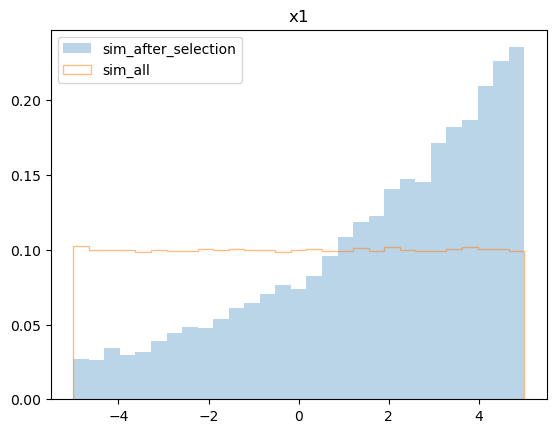

In [22]:
bins=X1_BINS
plt.hist(sim_x1,bins=bins,alpha=0.3,density=True,label='sim_after_selection')
plt.hist(sim_all_x1,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('x1')

Text(0.5, 1.0, 'c')

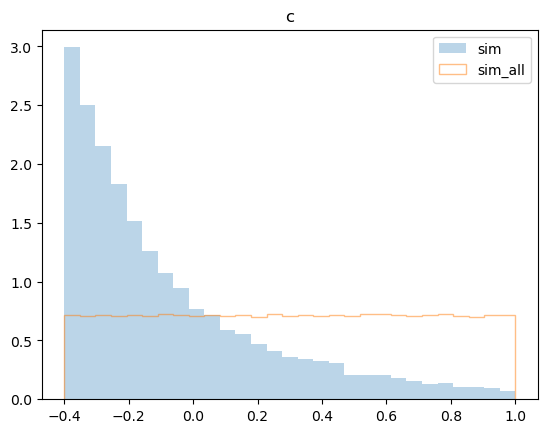

In [23]:
bins=C_BINS
plt.hist(sim_c,bins=bins,alpha=0.3,density=True,label='sim')
plt.hist(sim_all_c,bins=bins,alpha=0.5,density=True,label='sim_all',histtype='step')
plt.legend()
plt.title('c')

In [24]:
def expo(x, a, b, c):
    x = np.asarray(x)
    y = a * np.exp(b * x) + c
    return y

[ 0.04493352  0.21179256 -0.00379146]


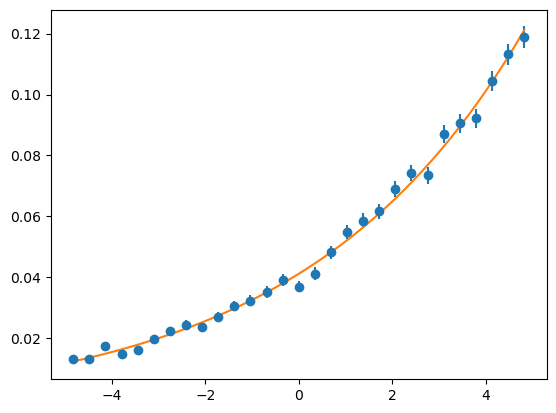

In [25]:
bins = X1_BINS
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
x_x1 = (bin_edges[:-1] + bin_edges[1:])/2.
f_x1 = x1after/x1before
err = np.sqrt(x1after**2/x1before**3 + x1after/x1before**2)

plt.errorbar(x_x1,f_x1,yerr=err,fmt='o')
outarr = np.array([x_x1,f_x1])

#fit for an exponential curve using curve_fit
popt, pcov = curve_fit(expo, x_x1, f_x1, p0=[1., 1. ,0.], sigma=err, bounds = ([0.0, 0.0, -np.inf], [np.inf, np.inf, np.inf]))
print(popt)
x = np.linspace(x_x1.min(),x_x1.max(),50)
plt.plot(x, expo(x, *popt))
np.savetxt('data/ztf_selection_func_x1.txt',popt)

[ 0.05614568 -3.35787237  0.00470503]


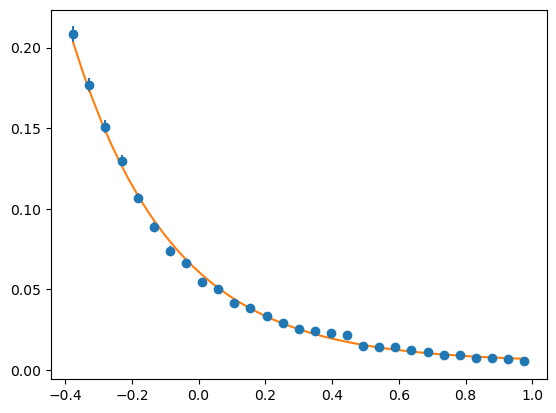

In [26]:
bins = C_BINS
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
x_c = (bin_edges[:-1] + bin_edges[1:])/2.
f_c = cafter/cbefore
err = np.sqrt(cafter**2/cbefore**3 + cafter/cbefore**2)
plt.errorbar(x_c,f_c,yerr=err,fmt='o')
outarr = np.array([x_c,f_c])

#fit for an exponential curve using curve_fit
popt, pcov = curve_fit(expo, x_c, f_c, p0=[1., -1. ,0.], sigma=err, bounds = ([0.0, -np.inf, -np.inf], [np.inf, 0.0, np.inf]))
print(popt)
x = np.linspace(x_c.min(),x_c.max(),50)
plt.plot(x, expo(x, *popt))
np.savetxt('data/ztf_selection_func_c.txt',popt)

[ 0.06453837 -0.86683046 -0.01987055]
offset from fitting to an exponential curve: -0.025051400196283696


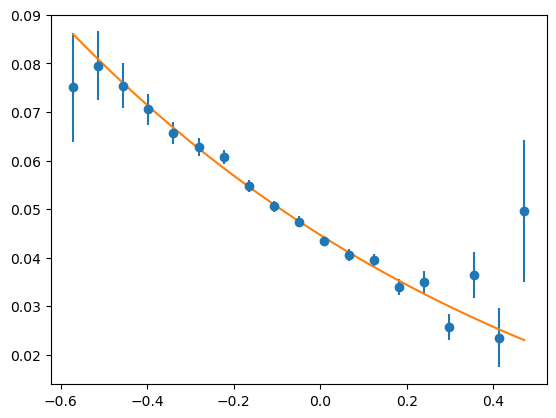

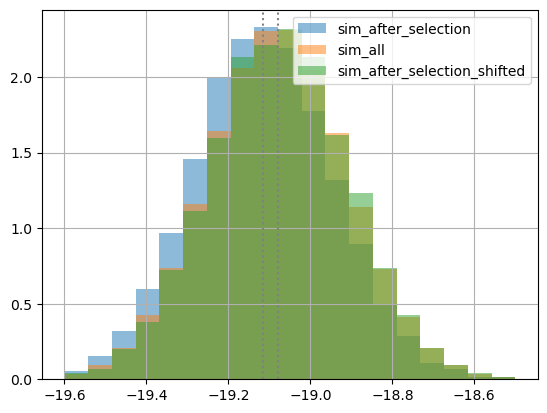

after_selection: -19.115112056914953
before_selection: -19.07999253761636
offset=-0.03511951929859336


In [27]:
sim_all_mabs = lightcurves['x0_func_m_abs']
sim_mabs = lightcurves_after_quality_cut['x0_func_m_abs']
bins = np.linspace(-19.6,-18.5,20)
mbefore,bin_edges,_ = stats.binned_statistic(sim_all_mabs, np.ones(len(lightcurves)), statistic='sum', bins=bins)
mafter,bin_edges,_ = stats.binned_statistic(sim_mabs,np.ones(len(lightcurves_after_quality_cut)), statistic='sum', bins=bins)
x_m = (bin_edges[:-1] + bin_edges[1:])/2. +19
f_m = mafter/mbefore
err = np.sqrt(mafter**2/mbefore**3 + mafter/mbefore**2)
plt.errorbar(x_m,f_m,yerr=err,fmt='o')
#fit for an exponential curve using curve_fit
popt, pcov = curve_fit(expo, x_m, f_m, p0=[1., -1. ,0.], sigma=err, bounds = ([0.0, -np.inf, -np.inf], [np.inf, 0.0, np.inf]))
print(popt)
print("offset from fitting to an exponential curve:", popt[1]*SIGMA_MAGABS**2)
x = np.linspace(x_m.min(),x_m.max(),50)
plt.plot(x, expo(x, *popt))
plt.show()

sim_mabs.hist(alpha=0.5,density=True,bins=bins,label='sim_after_selection')
sim_all_mabs.hist(alpha=0.5,density=True,bins=bins,label='sim_all')
(sim_mabs+0.04).hist(alpha=0.5,density=True,bins=bins,label='sim_after_selection_shifted')
plt.legend()
plt.axvline(x=np.mean(sim_mabs),color='grey',ls=':')
plt.axvline(x=np.mean(sim_all_mabs),color='grey',ls=':')
plt.show()
magabs_offset = np.mean(sim_mabs)-np.mean(sim_all_mabs)
print("after_selection:",np.mean(sim_mabs))
print("before_selection:",np.mean(sim_all_mabs))
print(f"offset={magabs_offset}")